In [1]:
%matplotlib inline
from roofline import RooflineModel, gemm_oi, hong_kung_oi, attention_oi, u55c_preset

In [2]:
m = RooflineModel()
m.add_compute("MXU INT8", 2048)
m.add_compute("Vector FP32", 128)
m.add_bw("SRAM", 8000)
m.add_bw("HBM", 460)
m.add_bw("PCIe", 16)
m.add_workload("GEMM (4096^2)", oi=gemm_oi(4096, 4096, 4096, elem_bytes=1))
m.add_workload("GEMM (512^2)", oi=gemm_oi(512, 512, 512, elem_bytes=1))
m.add_workload("Attention (S=2048)", oi=attention_oi(2048, 64))
m.add_workload("LayerNorm", oi=0.5)
m.add_workload("Softmax", oi=1.2)

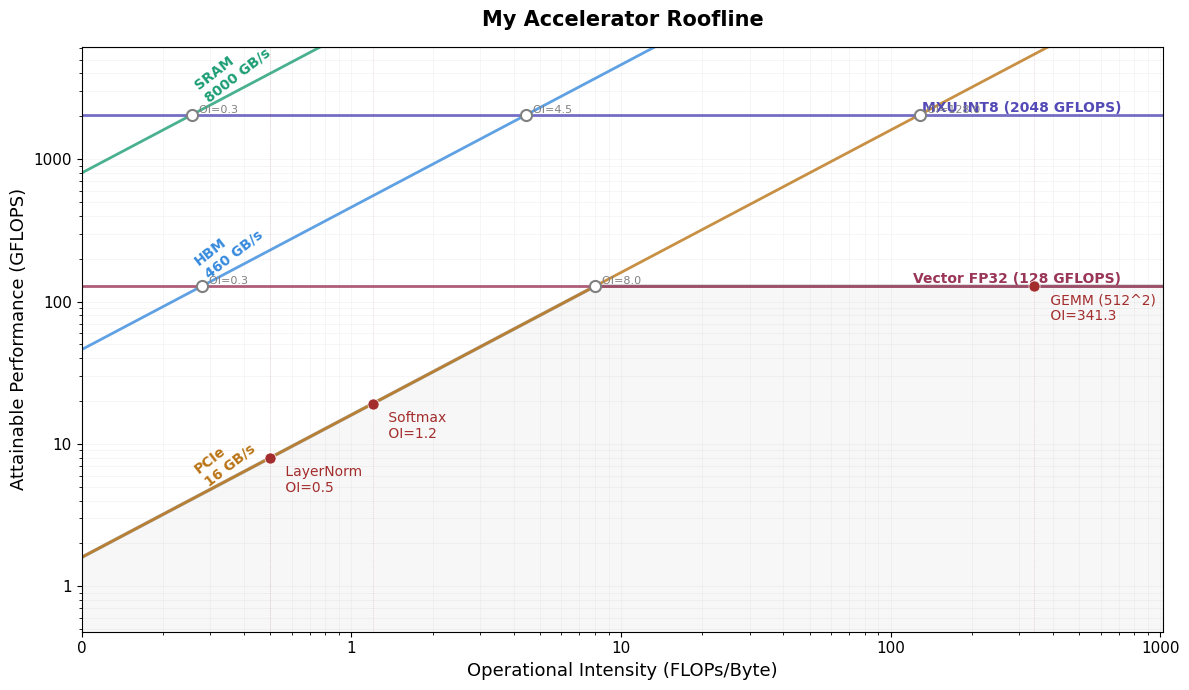

RIDGE POINTS
  MXU INT8 x SRAM:  OI = 0.26 FLOPs/B  (2048 GFLOPS)
  MXU INT8 x HBM:  OI = 4.45 FLOPs/B  (2048 GFLOPS)
  MXU INT8 x PCIe:  OI = 128.00 FLOPs/B  (2048 GFLOPS)
  Vector FP32 x SRAM:  OI = 0.02 FLOPs/B  (128 GFLOPS)
  Vector FP32 x HBM:  OI = 0.28 FLOPs/B  (128 GFLOPS)
  Vector FP32 x PCIe:  OI = 8.00 FLOPs/B  (128 GFLOPS)

WORKLOAD BOTTLENECK ANALYSIS
  Workload                        OI   Attainable Bottleneck           Regime             Resources
  ------------------------- -------- ------------ -------------------- ------------------ --------------------
  GEMM (4096^2)              2730.67      128.0  Vector FP32          compute-bound      (all)
  GEMM (512^2)                341.33      128.0  Vector FP32          compute-bound      (all)
  Attention (S=2048)         1351.26      128.0  Vector FP32          compute-bound      (all)
  LayerNorm                     0.50        8.0  PCIe                 memory-bound       (all)
  Softmax                       1.20      

In [3]:
m.plot(title="My Accelerator Roofline")
m.summary()